In [23]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import pipeline, set_seed 
import matplotlib.pyplot as plt

In [14]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')

text = "What is the capital of France?" 
encoded_input = tokenizer(text, return_tensors='pt')

output = model.generate(**encoded_input)

decoded_output = tokenizer.decode(output[0], skip_special_tokens=True)    
decoded_output

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2552.39it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'What is the capital of France?\n\nThe capital of France is Paris.\n\nThe capital of France is Paris.\n\n'

In [15]:
sd_hf = model.state_dict() 

for key, value in sd_hf.items():
    print(key, value.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

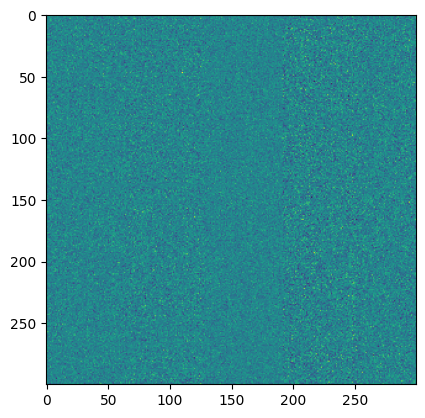

In [21]:
plt.imshow(sd_hf['transformer.h.0.attn.c_attn.weight'][:300, :300]) 
# plt.imshow(model.transformer.h.0.attn.c_proj)

In [24]:
generator = pipeline('text-generation', model='gpt2')
generator("Hello, I'm a language model", num_return_sequences=5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2468.36it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language modeler and I've written a blog about it here. I have a very broad view around the world. I have a lot of ideas about how we can build better, more interesting languages. I have lots of good ideas about how to make those languages more interesting, more usable, more readable and easier to learn.\n\nSo how do you get started?\n\nWe need to focus on the things that make us interesting, and the things that make us more interesting. The good news is, if you focus on the things that make you more interesting, it's actually the things that make us better.\n\nBut wait, there's more!\n\nWe have this problem! The thing you think about when you think about languages is how they can make us more interesting. They can make us more interesting!\n\nIf you focus on the things that make us more interesting, you're more likely to get more results. So if you're working with great language modelers who are very good at doing that job, you'll be able to get lots 